In [4]:
# %%
# ====================================================================
# 1. IMPORTS & CONFIGURATION
# ====================================================================
import os
import glob
import time
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Advanced Models Support
from sklearn.ensemble import RandomForestClassifier 
from tensorflow.keras.models import load_model 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, recall_score

import warnings
warnings.filterwarnings('ignore')

class Config:
    # --- PATHS ---
    DATA_DIR = "./data/"
    MODEL_DIR = "./model/rf_fixed/" # เปลี่ยนชื่อโฟลเดอร์ให้สื่อความหมาย
    SCALER_PATH = "./model/rf_fixed_scaler.save"
    
    # Path สำหรับ Model ช่วย (Feature Engineering)
    ISO_MODEL_PATH = './../models/IsolationForest/model/iso_model2.joblib'
    ISO_SCALER_PATH = './../models/IsolationForest/model/iso_scaler2.joblib'
    LSTM_MODEL_PATH = './../models/LSTM_Autoencoders/lstm_autoencoder_model_fit.h5'
    LSTM_SCALER_PATH = './../models/LSTM_Autoencoders/scaler_fit.save'
    
    # --- SETTINGS ---
    HORIZONS = [0] 
    SEQUENCE_LENGTH = 60
    TEST_KEYWORDS = ['label_for_dev105_test_prepared']
    
    RAW_COLS = ['rain', 'soil', 'temp', 'humi', 'geo']
    LABEL_COL = 'label'
    LABEL_MAP = {'normal': 0, 'warning': 1, 'critical': 2}
    
    # --- Data Strategy ---
    TARGET_SAMPLES = 10000     
    CLASS_WEIGHTS = {0: 1.0, 1: 2.0, 2: 3.0} # ใช้ร่วมกับ Sample Weight
    
    # --- FIXED PARAMETERS (ตามที่คุณระบุ) ---
    RF_PARAMS = {
        'n_estimators': 207,
        'max_depth': 12,
        'min_samples_split': 7,
        'min_samples_leaf': 1,
        'max_features': None, # None means use all features
        'n_jobs': -1,
        'random_state': 42,
        'verbose': 0,
        'bootstrap': True
    }

cfg = Config()
if not os.path.exists(cfg.MODEL_DIR): os.makedirs(cfg.MODEL_DIR)
np.random.seed(42); random.seed(42)

def log(msg): print(f"[INFO] {time.strftime('%H:%M:%S')} - {msg}")
print("✅ Config Loaded (Random Forest Fixed Params Edition).")

✅ Config Loaded (Random Forest Fixed Params Edition).


In [5]:
# %%
# ====================================================================
# 2. HELPER FUNCTIONS
# ====================================================================
def load_data():
    log("Scanning Data...")
    files = glob.glob(os.path.join(cfg.DATA_DIR, "*.csv"))
    if not files: files = glob.glob(os.path.join(cfg.DATA_DIR, "**/*.csv"), recursive=True)
    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f)
            df.columns = [str(c).lower().strip().replace('.1', '') for c in df.columns]
            rename_map = {'temperature':'temp', 'hum':'humi', 'humidity':'humi', 'devid':'devID', 'time':'timestamp', 'date':'timestamp'}
            new_cols = {c: rename_map[c] for c in df.columns if c in rename_map}
            if new_cols: df = df.rename(columns=new_cols)
            if 'devID' in df.columns: df['devID'] = df['devID'].astype(str).str.extract('(\d+)')[0].astype(float).fillna(0).astype(int)
            if 'timestamp' in df.columns: df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
            for c in cfg.RAW_COLS: 
                if c not in df.columns: df[c] = 0.0
            filename = os.path.basename(f)
            df['is_test'] = any(k in filename for k in cfg.TEST_KEYWORDS)
            dfs.append(df)
            print(f"   + Loaded: {filename} [{'TEST' if df['is_test'].iloc[0] else 'TRAIN'}]")
        except: pass
    return pd.concat(dfs, ignore_index=True) if dfs else None

def generate_features(df):
    log("Feature Engineering (Physics + AI Models)...")
    df = df.sort_values(['devID', 'timestamp']).reset_index(drop=True)
    df_list = []
    
    # Load Helper Models
    iso_model, iso_scaler = None, None
    lstm_model, lstm_scaler = None, None

    try:
        iso_model = joblib.load(cfg.ISO_MODEL_PATH)
        iso_scaler = joblib.load(cfg.ISO_SCALER_PATH)
        print("   -> Loaded Isolation Forest Model")
    except Exception as e: print(f"   [WARN] Could not load ISO Model: {e}")

    try:
        lstm_model = load_model(cfg.LSTM_MODEL_PATH, compile=False)
        lstm_scaler = joblib.load(cfg.LSTM_SCALER_PATH)
        print("   -> Loaded LSTM Autoencoder Model")
    except Exception as e: 
        print(f"   [WARN] Could not load LSTM Model: {e}")

    # Processing Loop
    for dev, g in df.groupby('devID'):
        g = g.set_index('timestamp')
        g = g[~g.index.duplicated(keep='first')]
        if len(g) > 0: g = g.resample('1T').asfreq()
        g[cfg.RAW_COLS] = g[cfg.RAW_COLS].interpolate(limit_direction='both').fillna(0)
        
        # --- Physics Features ---
        g['rain_1h'] = g['rain'].rolling(60, min_periods=1).sum()
        g['soil_rate'] = g['soil'].diff().fillna(0)
        g['soil_acc']  = g['soil'].diff().diff().fillna(0)
        g['rain_6h'] = g['rain'].rolling(360, min_periods=1).sum()
        g['soil_trend_6h'] = g['soil'] - g['soil'].shift(360).fillna(method='bfill')
        g['rain_24h'] = g['rain'].rolling(1440, min_periods=1).sum()
        g['soil_max_24h'] = g['soil'].rolling(1440, min_periods=1).max()
        g['rain_x_soil'] = g['rain'] * g['soil']
        
        # --- NEW FEATURES ---
        g['rain_ma_1h'] = g['rain'].rolling(60, min_periods=1).mean()
        g['soil_ma_12h'] = g['soil'].rolling(720, min_periods=1).mean()
        g['geo_ma_8m'] = g['geo'].rolling(8, min_periods=1).mean()
        
        # AI Features
        if iso_model and iso_scaler:
            try:
                X_iso = iso_scaler.transform(g[cfg.RAW_COLS].values)
                g['feat_iso_score'] = iso_model.decision_function(X_iso)
            except: g['feat_iso_score'] = 0.0
        else: g['feat_iso_score'] = 0.0
            
        if lstm_model and lstm_scaler:
            try:
                data_values = g[cfg.RAW_COLS].values
                X_lstm = lstm_scaler.transform(data_values)
                if X_lstm.ndim == 2: X_reshaped = X_lstm.reshape(X_lstm.shape[0], 1, X_lstm.shape[1]) 
                else: X_reshaped = X_lstm
                preds = lstm_model.predict(X_reshaped, verbose=0)
                mae = np.mean(np.abs(X_reshaped - preds), axis=2).flatten()
                g['feat_lstm_error'] = mae
            except: g['feat_lstm_error'] = 0.0
        else: g['feat_lstm_error'] = 0.0

        if cfg.LABEL_COL in g.columns:
            g[cfg.LABEL_COL] = g[cfg.LABEL_COL].fillna('normal').astype(str).str.lower().str.strip()
            g[cfg.LABEL_COL] = g[cfg.LABEL_COL].map(cfg.LABEL_MAP).fillna(0).astype(int)
        else: g[cfg.LABEL_COL] = 0
        g['is_test'] = g['is_test'].fillna(method='ffill').fillna(method='bfill')
        g['devID'] = dev
        df_list.append(g.reset_index())
        
    return pd.concat(df_list, ignore_index=True).fillna(0)

def create_sequences_vectorized(df, feature_cols, horizon):
    Xs, ys, is_tests = [], [], []
    for dev, g in df.groupby('devID'):
        data = g[feature_cols].values
        labels = g[cfg.LABEL_COL].shift(-horizon).values
        test_flag = g['is_test'].values
        valid_len = len(g) - horizon
        if valid_len < cfg.SEQUENCE_LENGTH: continue
        windows = np.lib.stride_tricks.sliding_window_view(data[:valid_len], window_shape=(cfg.SEQUENCE_LENGTH, len(feature_cols))).squeeze()
        windows_flat = windows.reshape(windows.shape[0], -1)
        target_labels = labels[cfg.SEQUENCE_LENGTH-1 : valid_len]
        target_tests = test_flag[cfg.SEQUENCE_LENGTH-1 : valid_len]
        min_len = min(len(windows_flat), len(target_labels))
        Xs.append(windows_flat[:min_len]); ys.append(target_labels[:min_len]); is_tests.append(target_tests[:min_len])
    if not Xs: return np.array([]), np.array([]), np.array([])
    return np.concatenate(Xs), np.concatenate(ys), np.concatenate(is_tests)

def balance_data(X, y):
    print(f"   Original counts: {Counter(y)}")
    X_bal, y_bal = [], []
    for cls in np.unique(y):
        if np.isnan(cls): continue
        indices = np.where(y == cls)[0]
        count = len(indices); target = cfg.TARGET_SAMPLES; replace = count < target
        n_samples = target if replace else count 
        chosen_indices = np.random.choice(indices, n_samples, replace=replace)
        X_bal.append(X[chosen_indices]); y_bal.append(y[chosen_indices])
    X_bal = np.concatenate(X_bal); y_bal = np.concatenate(y_bal)
    perm = np.random.permutation(len(X_bal))
    return X_bal[perm], y_bal[perm]

def evaluate_and_print(y_true, y_pred, title):
    print(f"\n{'='*20} {title} {'='*20}")
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    class_names = ['Normal', 'Warning', 'Critical']
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
    
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    print(f"{'='*50}\n")
    
def optimize_thresholds_for_safety(model, X_val, y_val_true):
    log("🔧 Tuning Safety Thresholds (RF)...")
    probs = model.predict_proba(X_val) 
    best_score = -1; best_thresh_crit = 0.5; best_thresh_warn = 0.5
    
    for t_crit in np.arange(0.1, 0.9, 0.05):
        for t_warn in np.arange(0.1, 0.9, 0.05):
            if t_warn >= t_crit: continue 
            preds = np.zeros(len(probs), dtype=int)
            crit_mask = probs[:, 2] >= t_crit; preds[crit_mask] = 2
            warn_mask = (~crit_mask) & (probs[:, 1] >= t_warn); preds[warn_mask] = 1
            
            rec_c = recall_score(y_val_true, preds, labels=[2], average=None, zero_division=0)[0] if 2 in np.unique(y_val_true) else 0
            f1_c = f1_score(y_val_true, preds, labels=[2], average=None, zero_division=0)[0] if 2 in np.unique(y_val_true) else 0
            f1_w = f1_score(y_val_true, preds, labels=[1], average=None, zero_division=0)[0] if 1 in np.unique(y_val_true) else 0
            score = (rec_c * 2.0) + f1_c + (f1_w * 0.5)
            
            if score > best_score:
                best_score = score; best_thresh_crit = t_crit; best_thresh_warn = t_warn
                
    print(f"   🔥 Best Thresholds -> Crit: {best_thresh_crit:.2f}, Warn: {best_thresh_warn:.2f}")
    return best_thresh_crit, best_thresh_warn

def predict_with_tuned_thresholds(model, X, t_crit, t_warn):
    probs = model.predict_proba(X)
    preds = np.zeros(len(probs), dtype=int)
    crit_mask = probs[:, 2] >= t_crit; preds[crit_mask] = 2
    warn_mask = (~crit_mask) & (probs[:, 1] >= t_warn); preds[warn_mask] = 1
    return preds

In [6]:
# %%
# ====================================================================
# 3. LOAD & FEATURE ENGINEERING (RUN ONCE)
# ====================================================================
df_train_raw = load_data()
df_proc = generate_features(df_train_raw)

FINAL_FEATURES = cfg.RAW_COLS + [
    'rain_1h', 'soil_rate', 'soil_acc', 'rain_6h', 'soil_trend_6h', 
    'rain_24h', 'soil_max_24h', 'rain_x_soil', 
    'rain_ma_1h', 'soil_ma_12h', 'geo_ma_8m',
    'feat_iso_score', 'feat_lstm_error'
]

log("Scaling Data (StandardScaler)...")
scaler = StandardScaler()
train_mask = ~df_proc['is_test']
scaler.fit(df_proc.loc[train_mask, FINAL_FEATURES])
df_proc[FINAL_FEATURES] = scaler.transform(df_proc[FINAL_FEATURES])
joblib.dump(scaler, cfg.SCALER_PATH)
print("✅ Data Ready.")

[INFO] 19:13:58 - Scanning Data...
   + Loaded: final_moving_avg_devID109_test_prepared.csv [TRAIN]
   + Loaded: label_for_dev105_test_prepared.csv [TEST]
   + Loaded: label_for_dev107_test_prepared.csv [TRAIN]
   + Loaded: label_for_dev108_test_prepared.csv [TRAIN]
   + Loaded: label_for_dev109_test_prepared.csv [TRAIN]
   + Loaded: monitoring_data_2025-11-22_19-57-13_prepared.csv [TRAIN]
   + Loaded: moving_avg_for_train_prepared.csv [TRAIN]
[INFO] 19:14:00 - Feature Engineering (Physics + AI Models)...
   -> Loaded Isolation Forest Model
   -> Loaded LSTM Autoencoder Model
[INFO] 19:14:01 - Scaling Data (StandardScaler)...
✅ Data Ready.



🚀 HORIZON: +0.0 Hours (0 mins)
⚖️ Balancing Train Data...
   Original counts: Counter({np.int64(0): 63421, np.int64(1): 1854, np.int64(2): 991})
🌲 Training Random Forest with Fixed Params: {'n_estimators': 207, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': None, 'n_jobs': -1, 'random_state': 42, 'verbose': 0, 'bootstrap': True}
   💾 Model Saved: ./model/rf_fixed/rf_fixed_h0.joblib

   📊 Top 5 Important Features:
      1. Feature idx 1074 (0.7124)
      2. Feature idx 1066 (0.0751)
      3. Feature idx 1062 (0.0426)
      4. Feature idx 1078 (0.0296)
      5. Feature idx 1073 (0.0262)

==================== TRAIN SET (Standard) - H0 ====================


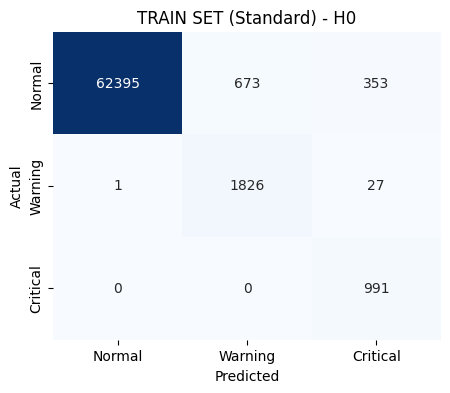

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     63421
     Warning       0.73      0.98      0.84      1854
    Critical       0.72      1.00      0.84       991

    accuracy                           0.98     66266
   macro avg       0.82      0.99      0.89     66266
weighted avg       0.99      0.98      0.99     66266



==================== VAL SET (Standard) - H0 ====================


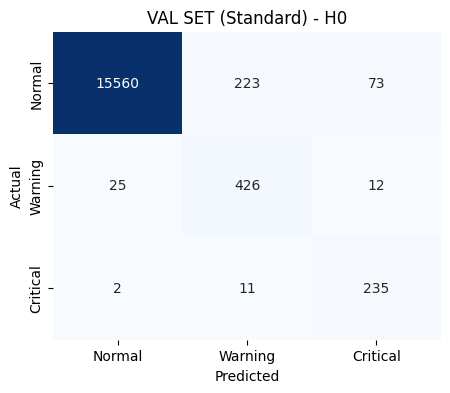

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     15856
     Warning       0.65      0.92      0.76       463
    Critical       0.73      0.95      0.83       248

    accuracy                           0.98     16567
   macro avg       0.79      0.95      0.86     16567
weighted avg       0.98      0.98      0.98     16567



==================== TEST SET (Standard) - H0 ====================


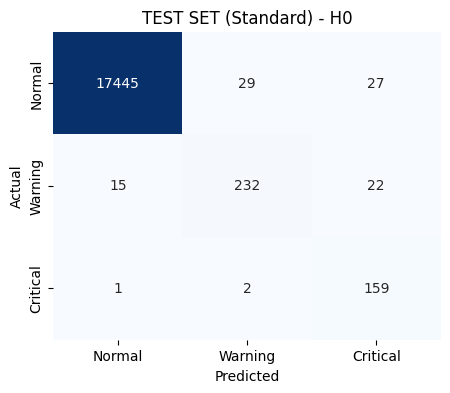

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     17501
     Warning       0.88      0.86      0.87       269
    Critical       0.76      0.98      0.86       162

    accuracy                           0.99     17932
   macro avg       0.88      0.95      0.91     17932
weighted avg       1.00      0.99      0.99     17932


[INFO] 19:38:28 - 🔧 Tuning Safety Thresholds (RF)...
   🔥 Best Thresholds -> Crit: 0.15, Warn: 0.10
[INFO] 19:38:29 - Evaluating Test Set (Tuned)...

==================== TEST SET (Tuned: C>0.15, W>0.10) ====================


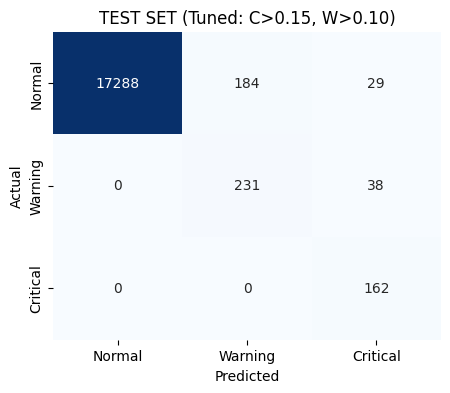

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     17501
     Warning       0.56      0.86      0.68       269
    Critical       0.71      1.00      0.83       162

    accuracy                           0.99     17932
   macro avg       0.75      0.95      0.83     17932
weighted avg       0.99      0.99      0.99     17932



=== FINAL SUMMARY (FIXED RF) ===
   Horizon       Acc   F1_Norm   F1_Warn   F1_Crit
0        0  0.986003  0.993877  0.675439  0.828645


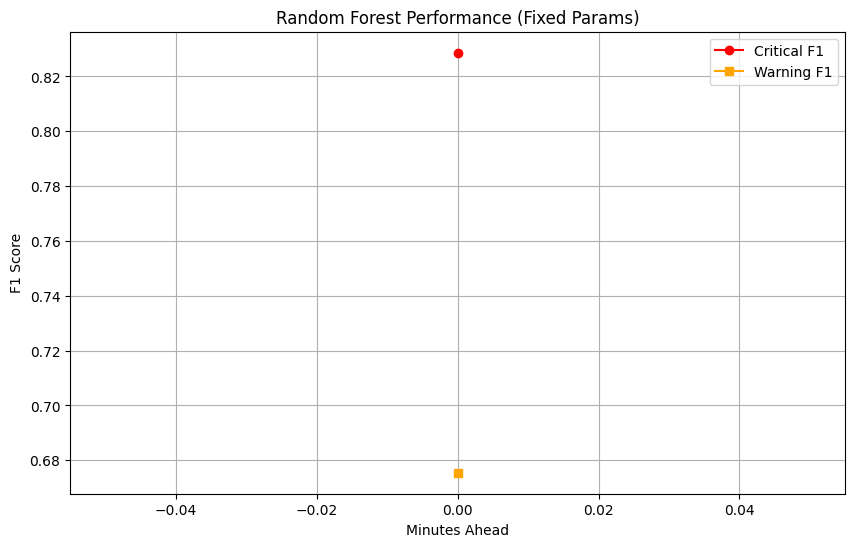

In [7]:
# %%
# ====================================================================
# 4. TRAINING WITH FIXED PARAMS
# ====================================================================

results_log = []

for h in cfg.HORIZONS:
    print(f"\n{'='*60}")
    print(f"🚀 HORIZON: +{h/60:.1f} Hours ({h} mins)")
    print(f"{'='*60}")
    
    # 1. Prepare & Split
    X_all, y_all, test_mask = create_sequences_vectorized(df_proc, FINAL_FEATURES, h)
    if len(X_all) == 0: 
        print("Skipping... No data.")
        continue
        
    X_train = X_all[~test_mask]; y_train = y_all[~test_mask]
    X_test  = X_all[test_mask];  y_test  = y_all[test_mask]
    
    valid_tr = ~np.isnan(y_train); X_train = X_train[valid_tr]; y_train = y_train[valid_tr]
    valid_ts = ~np.isnan(y_test);  X_test = X_test[valid_ts];   y_test = y_test[valid_ts]
    
    # Split Validation set from Train
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # 2. Balance & Weights
    print("⚖️ Balancing Train Data...")
    X_train_bal, y_train_bal = balance_data(X_train, y_train)
    
    # Sample Weights for Random Forest
    safety_factor = 1.0 + (h/1440.0)
    sample_weights = np.array([cfg.CLASS_WEIGHTS[y] * safety_factor for y in y_train_bal])
    
    # 3. Training with Fixed Params
    print(f"🌲 Training Random Forest with Fixed Params: {cfg.RF_PARAMS}")
    model = RandomForestClassifier(**cfg.RF_PARAMS)
    model.fit(X_train_bal, y_train_bal, sample_weight=sample_weights)
    
    # Save Model
    save_path = os.path.join(cfg.MODEL_DIR, f"rf_fixed_h{h}.joblib")
    joblib.dump(model, save_path)
    print(f"   💾 Model Saved: {save_path}")
    
    # Feature Importance Log
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    print("\n   📊 Top 5 Important Features:")
    for f in range(5):
        if f < len(FINAL_FEATURES):
             # Note: Features are flattened window, so this mapping is approximate for visualization
             print(f"      {f+1}. Feature idx {indices[f]} ({importances[indices[f]]:.4f})")
    
    # ==========================================================
    # 4. FULL EVALUATION
    # ==========================================================
    
    # 4.1 TRAIN SET
    y_train_pred = model.predict(X_train)
    evaluate_and_print(y_train, y_train_pred, f"TRAIN SET (Standard) - H{h}")

    # 4.2 VALIDATION SET
    y_val_pred = model.predict(X_val)
    evaluate_and_print(y_val, y_val_pred, f"VAL SET (Standard) - H{h}")
    
    # 4.3 TEST SET (Standard)
    y_test_pred_std = model.predict(X_test)
    evaluate_and_print(y_test, y_test_pred_std, f"TEST SET (Standard) - H{h}")

    # ==========================================================
    # 5. TUNED THRESHOLD EVALUATION
    # ==========================================================
    t_crit, t_warn = optimize_thresholds_for_safety(model, X_val, y_val)
    
    # Save Thresholds
    with open(os.path.join(cfg.MODEL_DIR, f"thresh_h{h}.txt"), "w") as f: f.write(f"{t_crit},{t_warn}")
    
    log(f"Evaluating Test Set (Tuned)...")
    y_pred_tuned = predict_with_tuned_thresholds(model, X_test, t_crit, t_warn)
    
    evaluate_and_print(y_test, y_pred_tuned, f"TEST SET (Tuned: C>{t_crit:.2f}, W>{t_warn:.2f})")
    
    # Logging
    acc = accuracy_score(y_test, y_pred_tuned)
    report = classification_report(y_test, y_pred_tuned, target_names=['Normal', 'Warning', 'Critical'], output_dict=True, zero_division=0)
    def get_rep(label): return report.get(label, {'f1-score':0})['f1-score']
    results_log.append({'Horizon': h, 'Acc': acc, 'F1_Norm': get_rep('Normal'), 'F1_Warn': get_rep('Warning'), 'F1_Crit': get_rep('Critical')})

# Final Summary
summary = pd.DataFrame(results_log)
print("\n=== FINAL SUMMARY (FIXED RF) ===")
print(summary)

plt.figure(figsize=(10, 6))
plt.plot(summary['Horizon'], summary['F1_Crit'], marker='o', color='red', label='Critical F1')
plt.plot(summary['Horizon'], summary['F1_Warn'], marker='s', color='orange', label='Warning F1')
plt.title("Random Forest Performance (Fixed Params)")
plt.xlabel("Minutes Ahead")
plt.ylabel("F1 Score")
plt.legend(); plt.grid(True)
plt.show()